# Research objective

This notebook studies **what drives firm-level carbon intensity in the European steel sector** and how emissions may evolve under different future policy and technology pathways.

We combine:
- **Panel econometrics** to identify statistically significant emission drivers
- **Machine learning** to capture firm-specific, non-linear behavior
- **Scenario analysis** to translate policy choices into future emissions

The focus is on understanding *mechanisms*, not just prediction accuracy.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import os
import itertools
import numpy as np
import pandas as pd
from linearmodels.panel import PanelOLS
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:


path = "data/EDA/emissions_and_production_technology.xlsx"

print("Exists:", os.path.exists(path))
print("Size in bytes:", os.path.getsize(path))

Exists: True
Size in bytes: 60002


In [3]:
# import data and immediate train test split
df_countries = pd.read_excel("data/EDA/external_drivers.xlsx",sheet_name='Sheet1')
df_countries





,country,year,carbon_price,electricity_price,electricity_price_eu,coal_price_australia,iron_ore_price,natural_gas_price,natural_gas_price_eu,crude_steel_production,...,govt_change_SE,govt_change_NL,govt_change_ES,govt_change_FI,govt_change_FR,govt_change_LU,govt_change_GB,govt_change_AT,EU_parl,EU_comm
0,Germany,2013,4.30,0.143450,0.11800,0.007407,92.871959,0.047850,0.04115,42.70000,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0,NaN,NaN
1,Germany,2014,5.90,0.155300,0.11980,0.006226,67.423384,0.042500,0.03835,42.90000,...,1.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN,1.0,1.0
2,Germany,2015,7.60,0.150100,0.11580,0.006929,51.436968,0.038600,0.03560,42.70000,...,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,NaN
3,Germany,2016,5.20,0.149850,0.11220,0.008110,56.131439,0.033550,0.03130,42.10000,...,NaN,NaN,NaN,NaN,1.0,NaN,1.0,1.0,NaN,NaN
4,Germany,2017,5.80,0.151650,0.11275,0.010277,65.261844,0.031200,0.02960,43.60000,...,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,Bulgaria-Greece,2021,52.50,0.147564,0.13685,0.013622,124.992665,0.037680,0.03605,1.00400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
152,Bulgaria-Greece,2022,80.32,0.206188,0.19720,0.035602,98.083782,0.095364,0.07615,0.99128,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
153,Bulgaria-Greece,2023,84.00,0.163820,0.20770,0.017881,97.748558,0.059730,0.07575,0.82116,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
154,Bulgaria-Greece,2024,65.00,0.149228,0.19130,0.013950,87.803137,0.043818,0.06295,0.87528,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 📌 Brief Conceptual Summary for This Cell

The table lists **steel companies** (rows) and different **client sectors** (columns).  
Each sector column is a **binary indicator**:

- `1` → This sector **is a client** of the company  
- `0` → This sector is **not a client** of the company  

---

## 🎯 Goal:

### Measure how strongly a steel firm is pressured by its downstream customers (automotive, wind, etc.) to decarbonize.

---

#### 🎛 Final Weighted Score (recommended):

| Sector column name                           |  Weight | Why                                                                          |
| -------------------------------------------- | ------: | ---------------------------------------------------------------------------- |
| **Construction/ Infrastructure (C/I)**       | **1.5** | Big volume, some public procurement pressure, but less strict than auto/wind |
| **Automotive/ Mobility (A/M)**               | **3.0** | Very strong Scope 3 & supplier CO₂ requirements (OEMs, SBTi, etc.)           |
| **Energy/Power (E/P)**                       | **2.0** | Grid & power infra decarbonization with increasing low-carbon steel specs    |
| **Wind/Solar Energy (W/S)**                  | **3.0** | Flagship green steel demand (wind towers, etc.)                              |
| **Oil & Gas/ Pipelines (O/G)**               | **0.8** | Transition slower, weaker low-carbon procurement so far                      |
| **Mechanical Eng./ Industrial Apps (ME/IA)** | **1.5** | Medium pressure via industrial decarb + corporate targets                    |
| **Railways/ Track Systems (R/TS)**           | **2.5** | Strong EU green public procurement / infrastructure decarb                   |
| **Aerospace/ Aviation (A/A)**                | **1.2** | Highly regulated but low steel volume, niche                                 |
| **HH Appliances/ Consumer Goods (HA/CG)**    | **1.2** | Consumer brands starting Scope 3 work, but pressure moderate                 |
| **Packaging/Food Industry (P/FI)**           | **1.0** | Some sustainability focus, but steel share relatively small                  |





In [4]:
df_clients = pd.read_excel("data/EDA/clients_of_firms.xlsx",sheet_name='Sheet1')



weights = {
    "Construction/ Infrastructure (C/I)": 1.5,
    "Automotive/ Mobility (A/M)": 3.0,
    "Energy/Power (E/P)": 2.0,
    "Wind/Solar Energy (W/S)": 3.0,
    "Oil & Gas/ Pipelines (O/G)": 0.8,
    "Mechanical Eng./ Industrial Apps (ME/IA)": 1.5,
    "Railways/ Track Systems (R/TS)": 2.5,
    "Aerospace/ Aviation (A/A)": 1.2,
    "HH Appliances/ Consumer Goods (HA/CG)": 1.2,
    "Packaging/Food Industry (P/FI)": 1.0
}


# Weighted pressure score
df_clients['client_pressure_score'] = sum(
    df_clients[col] * w for col, w in weights.items()
)

df_clients


,company,Construction/ Infrastructure (C/I),Automotive/ Mobility (A/M),Energy/Power (E/P),Wind/Solar Energy (W/S),Oil & Gas/ Pipelines (O/G),Mechanical Eng./ Industrial Apps (ME/IA),Railways/ Track Systems (R/TS),Aerospace/ Aviation (A/A),HH Appliances/ Consumer Goods (HA/CG),Packaging/Food Industry (P/FI),client_pressure_score
0,Acerinox EU,1,1,1,0,1,1,0,1,0,1,11.0
1,Acciaierie d’Italia Holding,1,1,1,0,0,1,0,0,1,1,10.2
2,ArcelorMittal,1,1,1,1,1,0,1,0,0,1,13.8
3,ArcelorMittal Europe,1,1,1,1,1,0,1,0,0,1,13.8
4,Celsa Group,1,1,1,0,0,1,0,0,0,0,8.0
5,SHS Group,1,1,1,0,0,1,1,0,0,0,10.5
6,Dillinger DE,1,0,1,1,1,1,0,0,0,0,8.8
7,Dillinger FR,1,0,1,1,1,1,0,0,0,0,8.8
8,Outokumpu,1,1,1,1,0,1,0,0,1,0,12.2
9,Salzgitter AG,1,1,1,1,1,1,0,0,1,0,13.0


In [5]:
df_firms = pd.read_excel("data/EDA/emissions_and_production_technology.xlsx",sheet_name='emissions_steel_production')
df_firms.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   company                  137 non-null    object 
 1   country                  137 non-null    object 
 2   technology               137 non-null    object 
 3   year                     137 non-null    int64  
 4   production               136 non-null    float64
 5   scope1                   119 non-null    float64
 6   scope2_location          109 non-null    float64
 7   scope2_market            45 non-null     float64
 8   scope_1_2_location       106 non-null    float64
 9   intensity_location_co2e  114 non-null    float64
 10  intensity_market_co2e    39 non-null     float64
 11  data_quality             137 non-null    object 
 12  notes                    125 non-null    object 
dtypes: float64(7), int64(1), object(5)
memory usage: 14.0+ KB


In [6]:
df_firms['year'] = df_firms['year'].astype(int)
df_firms = df_firms.merge(df_countries, on=['country','year'], how='left')



In [7]:
df_firms = df_firms.copy()
df_clients = df_clients.copy()

# Clean whitespace
df_firms['company'] = df_firms['company'].str.strip()
df_clients['company'] = df_clients['company'].str.strip()

df_firms = df_firms.merge(df_clients, on=['company'], how='left')

df_firms['carbon_intensity'] = df_firms['scope1'] / df_firms['production']
df_firms = df_firms.reset_index(drop=True)
df_firms.to_csv("firms_df.csv", index=False)





In [8]:
# Work on a copy
df_panel = df_firms.copy()

# Columns that must be present
needed_cols = [
    'company', 'year',
    'production', 'scope1','electricity_price','SCI'
]

# 1) Drop rows with any missing in needed_cols
df_panel = df_panel.dropna(subset=needed_cols)

# 2) Ensure correct types
df_panel['year'] = df_panel['year'].astype(int)

# 3) Count obs per firm
obs_per_firm = df_panel.groupby('company').size()

# 4) Firms with ≥ 3 years of data
valid_firms = obs_per_firm[obs_per_firm >= 3].index
dropped_firms = obs_per_firm[obs_per_firm < 3].index

# 5) Keep only valid firms
df_panel = df_panel[df_panel['company'].isin(valid_firms)]

# 6) Set panel index
df_panel = df_panel.set_index(['company', 'year']).sort_index()

# Some diagnostics
print("Kept firms:", list(valid_firms))
print("Dropped firms (< 3 years):", list(dropped_firms))
print("Unique firms:", df_panel.index.get_level_values('company').nunique())
print("Unique years:", df_panel.index.get_level_values('year').nunique())

# Companies that remain
years_per_company = (
    df_panel
    .reset_index()  # brings firm_id and year back as columns
    .groupby('company')['year']
    .apply(lambda s: sorted(s.unique()))  # list of years for each company
)

print(years_per_company)









Kept firms: ["Acciaierie d'Italia Holding", 'Acerinox EU', 'ArcelorMittal', 'Celsa Group', 'Feralpi Group', 'Outokumpu', 'SHS Group', 'SIDENOR Group', 'SSAB', 'Salzgitter AG', 'Tata Steel Nederland', 'Voestalpine']
Dropped firms (< 3 years): ['Tata Steel UK']
Unique firms: 12
Unique years: 12
company
Acciaierie d'Italia Holding                             [2019, 2020, 2021, 2022]
Acerinox EU                                 [2019, 2020, 2021, 2022, 2023, 2024]
ArcelorMittal                  [2013, 2014, 2015, 2016, 2017, 2018, 2019, 202...
Celsa Group                                       [2020, 2021, 2022, 2023, 2024]
Feralpi Group                  [2013, 2014, 2015, 2016, 2017, 2018, 2019, 202...
Outokumpu                      [2013, 2014, 2015, 2016, 2017, 2018, 2019, 202...
SHS Group                       [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
SIDENOR Group                                     [2020, 2021, 2022, 2023, 2024]
SSAB                           [2013, 2014, 2015, 

In [9]:
df_panel['CBAM'] = pd.to_numeric(df_panel['CBAM'], errors='coerce').fillna(0).astype(int)
df_panel['CSP_funding'] = pd.to_numeric(df_panel['CSP_funding'], errors='coerce').fillna(0).astype(int)
df_panel['govt_change'] = pd.to_numeric(df_panel['govt_change'], errors='coerce').fillna(0).astype(int)

df_panel['CBAM_carbon'] = df_panel['CBAM'] * df_panel['carbon_price']
df_panel['funding_carbon'] = df_panel['CSP_funding'] * df_panel['carbon_price']
df_panel['govt_carbon'] = df_panel['govt_change'] * df_panel['carbon_price'] 
df_panel.reset_index(inplace=True)
df_panel = df_panel[
    ~df_panel['company'].str.contains("ArcelorMittal", case=False, na=False)
].copy()
df_panel.set_index(['company','year'],inplace=True)

# 📘 PanelOLS setup (applies to all models)
### Model specification

- **Time fixed effects = True**  
  Controls for shocks that affect *all firms in the same year*  
  (e.g. ETS phase changes, energy crises, macroeconomic conditions).

- **Entity (firm) fixed effects = False**  
  We do **not** difference out firm identity because:
  - technology differences are explicitly modeled (BF-BOF, EAF, hydrogen)
  - we want to retain between-firm variation

- **Standard errors clustered by firm**  
  Allows for serial correlation and heteroskedasticity within firms over time.


## Exhaustive PanelOLS model search (driver selection)

### Why we use this function
We have many candidate **external drivers** (policy, energy, macro, etc.), and we want a **transparent + reproducible** way to test:
- which variables (or combinations of variables) best explain carbon intensity,
- without manually trying dozens of regressions.

This function runs many PanelOLS models and ranks them using an information criterion (**BIC/AIC**) or goodness-of-fit (**R² variants**).  
It helps us identify **the most parsimonious set of drivers** (strong explanatory power without overfitting).

---

### What it does (high-level)
For every possible subset of the candidate variables:
1. Builds a regression `CI ~ const + (subset of external_vars)`
2. Fits a **PanelOLS** model with optional **time effects** and **entity effects**
3. Computes and stores:
   - **AIC / BIC** (penalize overly complex models)
   - **R² overall / within / between** (where the explanatory power comes from)
4. Returns a ranked table of models, so we can quickly compare top candidates.

---

### Why BIC/AIC matter here
- **R² increases** when you add more variables (even useless ones).
- **AIC/BIC** reward fit but penalize complexity.
- In driver selection, we usually prefer:
  - **Lower BIC** → best balance of simplicity + explanatory power  
  - (AIC is similar but penalizes complexity less strongly than BIC)

---

### Why fixed effects options matter
- `time_effects=True`: controls for **EU-wide/year shocks** affecting all firms (e.g., macro events, common policy shifts).
- `entity_effects=True`: controls for **firm-specific unobserved differences** that are stable over time (e.g., plant design, baseline efficiency).
We toggle these to test whether results depend on unobserved firm heterogeneity vs. common time shocks.

---

### Why clustering options matter
We can cluster standard errors to handle correlation in residuals:
- `cluster_entity=True`: errors can be correlated within the same firm over time (common in panels).
- `cluster_time=True`: errors can be correlated within the same year across firms (common shocks).

Clustering affects inference (p-values / SEs), not the point estimates.

---

### Output: how to read it
The returned DataFrame contains one row per model combination:
- `variables`: which drivers were included
- `bic` / `aic`: model selection metrics (lower = better)
- `r2`, `r2_within`, `r2_between`: explanatory power by variation source

We typically inspect:
- the top ~5 models by BIC,
- and check if the same drivers appear repeatedly (robustness).


In [10]:
def search_panel_models(
    df_panel,
    y,
    external_vars,
    entity_effects=False,
    time_effects=False,
    sort_by="bic",
    cov_type="clustered",
    cluster_entity=False,
    cluster_time=False,
    max_combos=None,
):
    """
    Exhaustively search combinations of external_vars in a PanelOLS model.

    Parameters
    ----------
    df_panel : pd.DataFrame
        Panel data (MultiIndex: entity, time).
    y : str or pd.Series
        Dependent variable (column name or Series aligned with df_panel).
    external_vars : list
        List of column names to try in combinations.
    entity_effects : bool, default False
        Whether to include entity (firm) fixed effects.
    time_effects : bool, default True
        Whether to include time fixed effects.
    sort_by : {"bic", "aic", "r2", "r2_within", "r2_between"}, default "bic"
        Metric to sort the resulting DataFrame by.
    cov_type : str, default "clustered"
        Covariance type passed to PanelOLS.fit().
    cluster_entity : bool, default True
        Whether to cluster by entity in PanelOLS.fit().
    max_combos : int or None, default None
        Optional cap on number of combinations to estimate
        (in case the search space is very large).

    Returns
    -------
    results_df : pd.DataFrame
        DataFrame of model results for each combination.
    """

    # Get y as a Series if passed as column name
    if isinstance(y, str):
        y_series = df_panel[y]
    else:
        y_series = y

    results = []
    combos_count = 0

    for k in range(1, len(external_vars) + 1):
        for combo in itertools.combinations(external_vars, k):

            # Optional cap on number of combos
            combos_count += 1
            if max_combos is not None and combos_count > max_combos:
                break

            try:
                X = df_panel[list(combo)]
                X = sm.add_constant(X)

                mod = PanelOLS(
                    y_series, X,
                    entity_effects=entity_effects,
                    time_effects=time_effects
                ).fit(cov_type=cov_type, cluster_entity=cluster_entity, cluster_time=cluster_time)

                # number of parameters (including constant)
                k_params = len(mod.params)
                n_obs = mod.nobs
                llf = mod.loglik

                # Information criteria
                aic = 2 * k_params - 2 * llf
                bic = np.log(n_obs) * k_params - 2 * llf

                # R-squared variants (use getattr to be safe)
                r2_within = getattr(mod, 'rsquared_within', np.nan)
                r2_between = getattr(mod, 'rsquared_between', np.nan)
                r2 = getattr(mod, 'rsquared', np.nan)

                results.append({
                    'n_vars': k,
                    'variables': combo,
                    'aic': aic,
                    'bic': bic,
                    'r2_within': r2_within,
                    'r2_between': r2_between,
                    'r2': r2
                })

            except Exception as e:
                #print(f"Skipped combo {combo} due to error: {e}")
                continue

        # Respect max_combos across outer loop too
        if max_combos is not None and combos_count > max_combos:
            break

    if not results:
        print("No valid model combinations were estimated.")
        return pd.DataFrame()

    results_df = pd.DataFrame(results)

    if sort_by in results_df.columns:
        if sort_by in ["aic", "bic"]:
            # Lower AIC/BIC = better
            results_df = results_df.sort_values(sort_by, ascending=True)
        elif "r2" in sort_by:
            # Higher R² metrics = better
            results_df = results_df.sort_values(sort_by, ascending=False)
        else:
            # Unknown metric → default to BIC
            results_df = results_df.sort_values("bic", ascending=True)
    else:
        #If metric not found, fallback to BIC
        results_df = results_df.sort_values("bic", ascending=True)

    results_df = results_df.reset_index(drop=True)


    pd.set_option('display.max_colwidth', None)
    return results_df


## PanelOLS (BF firms + hydrogen terms): does hydrogen shift emissions?

**Purpose:** Test whether hydrogen adoption is associated with lower carbon intensity in BF contexts, and whether its effect depends on policy pressure.

- **Hydrogen use (−3.63, p = 0.031)**  
  Statistically significant and negative.  
  Hydrogen adoption is associated with lower carbon intensity, though the magnitude is moderate.

- **ETS × Hydrogen (+3.45, p = 0.075)**  
  Positive and marginally significant.  
  Suggests that policy pressure may attenuate hydrogen’s emissions-reducing effect, but evidence is weak and sample-sensitive.

- **ETS free allowance ratio (−1.54, p = 0.189)**  
  Not statistically significant.  
  No clear evidence that free allowance allocation amplifies hydrogen’s impact in this specification.

- **SCI (−0.11, p = 0.001)**  
  Strongly significant and negative.  
  Structural/system-level improvements are a key driver of lower carbon intensity, independent of hydrogen adoption.

- **Electricity price (+2.69, p = 0.619)**  
  Not statistically significant.  
  No detectable relationship in this small sample.

- **Client pressure score (p = 0.984)**  
  Not statistically significant.  
  No measurable effect in this model.

**Model fit**  
Overall explanatory power is moderate (R² ≈ 0.65), but the joint F-test is not significant, reflecting limited statistical power due to the small panel.

**Takeaway**  
Hydrogen adoption is associated with lower carbon intensity on average, but the effect is modest and not robust to policy interactions. Structural improvements dominate emissions outcomes, while policy-conditioning effects of hydrogen remain suggestive rather than conclusive.



In [11]:
# 1. Start from BF firms with hydrogen data
subset_BF = df_panel[
    (~df_panel['hydrogen_use'].isna()) &
    (df_panel['technology'].str.contains('BF', case=False))
].copy()

subset_BF.reset_index(inplace=True)

# Quick check: how many obs per company in this subset?
print("Obs per BF+H2 company BEFORE filtering:")
print(subset_BF['company'].value_counts())
print()

# 2. Keep only companies with > 3 observations
counts = subset_BF.groupby('company').size()
valid_firms = counts[counts > 3].index

subset_BF = subset_BF[subset_BF['company'].isin(valid_firms)].copy()

print("Obs per BF+H2 company AFTER filtering (>3 obs):")
print(subset_BF['company'].value_counts())
print()

# 3. Build interaction and model variables
subset_BF['ETSxH2'] = subset_BF['ETS_free_ratio'] * subset_BF['hydrogen_use']
subset_BF = subset_BF.set_index(["company", "year"])

Obs per BF+H2 company BEFORE filtering:
company
Salzgitter AG                  9
SHS Group                      8
Tata Steel Nederland           6
Acciaierie d'Italia Holding    4
SSAB                           1
Name: count, dtype: int64

Obs per BF+H2 company AFTER filtering (>3 obs):
company
Salzgitter AG                  9
SHS Group                      8
Tata Steel Nederland           6
Acciaierie d'Italia Holding    4
Name: count, dtype: int64



In [12]:
external_vars = [
                'ETS_free_ratio',
               'hydrogen_use',
               'ETSxH2',
               'electricity_price',
               'SCI','client_pressure_score'
]

y = subset_BF['carbon_intensity']


results_df = search_panel_models(
    df_panel=subset_BF,
    y=y,
    external_vars=external_vars,
    entity_effects=False,
    time_effects=True,
    sort_by="r2_between",
    cluster_entity=True
)

results_df.head(5)

c:\Users\aposk\ds_ai\SusteelAible\.venv\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
c:\Users\aposk\ds_ai\SusteelAible\.venv\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
c:\Users\aposk\ds_ai\SusteelAible\.venv\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
c:\Users\aposk\ds_ai\SusteelAible\.venv\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent

,n_vars,variables,aic,bic,r2_within,r2_between,r2
0,4,"(ETSxH2, electricity_price, SCI, client_pressure_score)",-39.339986,-33.662514,-0.349354,0.998096,0.548608
1,3,"(ETSxH2, electricity_price, client_pressure_score)",-41.310136,-36.768159,-0.255566,0.997434,0.548022
2,4,"(ETS_free_ratio, hydrogen_use, SCI, client_pressure_score)",-38.553508,-32.876037,0.078245,0.996751,0.532906
3,3,"(hydrogen_use, SCI, client_pressure_score)",-40.506072,-35.964095,0.075317,0.996514,0.531942
4,3,"(ETS_free_ratio, hydrogen_use, client_pressure_score)",-40.234256,-35.692279,0.039662,0.996347,0.526378


In [13]:
y = subset_BF['carbon_intensity']

X = sm.add_constant(
    subset_BF[['ETS_free_ratio',
               'hydrogen_use',
               'ETSxH2',
               'electricity_price',
               'SCI','client_pressure_score']]
)

# 4. Run the panel model
mod_H1 = PanelOLS(
    y, X,
    entity_effects=False,
    time_effects=True
).fit(cov_type='clustered', cluster_entity=True)

print(mod_H1.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:       carbon_intensity   R-squared:                        0.6457
Estimator:                   PanelOLS   R-squared (Between):              0.9939
No. Observations:                  23   R-squared (Within):              -0.5900
Date:                Tue, Feb 10 2026   R-squared (Overall):              0.1544
Time:                        12:05:27   Log-likelihood                    27.454
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2.4295
Entities:                           3   P-value                           0.1222
Avg Obs:                       7.6667   Distribution:                     F(6,8)
Min Obs:                       6.0000                                           
Max Obs:                       9.0000   F-statistic (robust):         -7.234e+11
                            

c:\Users\aposk\ds_ai\SusteelAible\.venv\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


## PanelOLS (BF-BOF subset): what drives emissions in high-emitting routes?

**Purpose:** Focus on BF-BOF firms to isolate drivers within the most carbon-intensive technology group.

**Why this matters:** BF-BOF dominates the emissions problem; this subset tests whether policy and energy signals explain variation *within* BF firms (not just between BF vs EAF).

- **ETS free allowance ratio (+0.18, p = 0.037)**  
  Statistically significant and positive.  
  Higher free allowance allocations are associated with higher carbon intensity, suggesting weaker decarbonization incentives.

- **Electricity price (+1.15, p = 0.005)**  
  Statistically significant and positive.  
  Rising electricity costs are linked to higher emissions, consistent with cost pressures discouraging cleaner inputs or processes.

- **SCI (+0.29, p = 0.033)**  
  Statistically significant and positive.  
  Higher country-level steel intensity is associated with higher emissions within BF-BOF firms, reflecting structural constraints.

- **Client pressure (+0.05, p = 0.079)**  
  Marginally significant and positive.  
  Suggests weak or inconsistent demand-side pressure for decarbonization.

**Model fit**  
The model shows good explanatory power (R² ≈ 0.62) and strong joint significance, indicating that policy, cost, and structural factors jointly explain variation within BF-BOF firms.

**Takeaway**  
Within BF-BOF firms, emissions respond systematically to policy design, energy costs, and structural context. Free allowances and high electricity prices are associated with higher carbon intensity, while client pressure remains weak. This suggests that institutional and cost conditions meaningfully shape outcomes, even within technologically locked-in routes.




In [14]:
BF_all = df_panel[df_panel['technology'].str.contains('BF', case=False)].copy()

In [15]:


y = BF_all['carbon_intensity']
X = sm.add_constant( BF_all[['ETS_free_ratio',
               'electricity_price',
               'SCI','client_pressure_score']])

mod_H2 = PanelOLS(
    y, X,
    entity_effects=False,
    time_effects=True
).fit(cov_type='clustered', cluster_entity=True)

print(mod_H2.summary)

c:\Users\aposk\ds_ai\SusteelAible\.venv\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


                          PanelOLS Estimation Summary                           
Dep. Variable:       carbon_intensity   R-squared:                        0.6173
Estimator:                   PanelOLS   R-squared (Between):              0.8851
No. Observations:                  42   R-squared (Within):              -1.1853
Date:                Tue, Feb 10 2026   R-squared (Overall):              0.4257
Time:                        12:05:27   Log-likelihood                    40.562
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      10.484
Entities:                           5   P-value                           0.0000
Avg Obs:                       8.4000   Distribution:                    F(4,26)
Min Obs:                       6.0000                                           
Max Obs:                       12.000   F-statistic (robust):             281.78
                            

## PanelOLS (BF-BOF subset): what drives emissions in high-emitting routes?

**Purpose:** Focus on BF-BOF firms to isolate drivers within the most carbon-intensive technology group.

**Why this matters:** BF-BOF dominates the emissions problem; this subset tests whether policy and energy signals explain variation *within* BF firms (not just between BF vs EAF).

- **ETS free allowance ratio (+0.18, p = 0.037)**  
  Statistically significant and positive.  
  Higher free allowance allocations are associated with higher carbon intensity, suggesting weaker decarbonization incentives.

- **Electricity price (+1.15, p = 0.005)**  
  Statistically significant and positive.  
  Rising electricity costs are linked to higher emissions, consistent with cost pressures discouraging cleaner inputs or processes.

- **SCI (+0.29, p = 0.033)**  
  Statistically significant and positive.  
  Higher country-level steel intensity is associated with higher emissions within BF-BOF firms, reflecting structural constraints.

- **Client pressure (+0.05, p = 0.079)**  
  Marginally significant and positive.  
  Suggests weak or inconsistent demand-side pressure for decarbonization.

**Model fit**  
The model shows good explanatory power (R² ≈ 0.62) and strong joint significance, indicating that policy, cost, and structural factors jointly explain variation within BF-BOF firms.

**Takeaway**  
Within BF-BOF firms, emissions respond systematically to policy design, energy costs, and structural context. Free allowances and high electricity prices are associated with higher carbon intensity, while client pressure remains weak. This suggests that institutional and cost conditions meaningfully shape outcomes, even within technologically locked-in routes.



In [16]:
# Filter to EAF technology observations
df_eaf = df_panel[df_panel['technology'].str.contains("EAF", case=False)].copy()
df_eaf = df_eaf.dropna(subset=[
    'carbon_intensity',
    'electricity_price',
    'SCI',
    'ETS_free_ratio',
    'client_pressure_score'
])


y_eaf = df_eaf['carbon_intensity']
X_eaf = sm.add_constant(df_eaf[['electricity_price', 'SCI', 'ETS_free_ratio', 'client_pressure_score']])

model_eaf = PanelOLS(
    y_eaf, X_eaf,
    entity_effects=False,
    time_effects=True
).fit(cov_type='clustered', cluster_entity=True)

print(model_eaf.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:       carbon_intensity   R-squared:                        0.9466
Estimator:                   PanelOLS   R-squared (Between):              0.9032
No. Observations:                  40   R-squared (Within):              -9.0238
Date:                Tue, Feb 10 2026   R-squared (Overall):              0.7657
Time:                        12:05:27   Log-likelihood                    72.476
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      106.34
Entities:                           5   P-value                           0.0000
Avg Obs:                       8.0000   Distribution:                    F(4,24)
Min Obs:                       5.0000                                           
Max Obs:                       12.000   F-statistic (robust):             98.255
                            

In [17]:
tech_summary = (
    df_panel
    .groupby('technology')['carbon_intensity']
    .agg(['mean','median','min','max'])
    .round(3)
)

print(tech_summary)

                mean  median    min    max
technology                                
BF-BOF         1.673   1.600  1.247  2.541
EAF            0.161   0.109  0.080  0.404
EAF Stainless  0.468   0.475  0.400  0.531


In [18]:
df_panel.reset_index(inplace=True)
df_panel['company'].unique()


array(["Acciaierie d'Italia Holding", 'Acerinox EU', 'Celsa Group',
       'Feralpi Group', 'Outokumpu', 'SHS Group', 'SIDENOR Group', 'SSAB',
       'Salzgitter AG', 'Tata Steel Nederland', 'Voestalpine'],
      dtype=object)

## PanelOLS (All firms): policy, energy, and technology exposure

**Purpose:** Estimate which external drivers are statistically associated with firm carbon intensity across the full sample.

**How to interpret key terms:**

##### **ETS × BF** captures “ETS pressure *where it matters*” (BF-BOF firms).
- **ETS × BF-BOF (+0.87, p < 0.001)**  
  Strong and highly significant.  
  Firms exposed to ETS through BF-BOF technology have substantially higher carbon intensity.  
  → Technology exposure is the dominant driver of emissions.

##### **ETS_free_ratio** reflects how much ETS pressure is softened by free allocation.
- **ETS free allowance ratio (−0.45, p < 0.001)**  
  Strongly significant and negative.  
  Lower free allocation increases effective carbon pressure and is associated with lower emissions.

##### **electricity_price** proxies energy cost pressure (especially relevant for electrified routes).
- **Electricity price (+1.32, p = 0.071)**  
  Marginally significant and positive.  
  Suggests that higher energy costs may be associated with higher carbon intensity, though evidence is weak.

##### **SCI** is a country-level sector intensity indicator (system-wide background conditions).
- **SCI (+0.38, p = 0.002)**  
  Statistically significant and positive.  
  Country-level steel system intensity is strongly correlated with firm emissions.

##### **client_pressure** is a firm-level indicator capturing downstream climate expectations.
- **Client pressure score (+0.04, p = 0.099)**  
  Marginally significant.  
  Weak evidence of a positive association with carbon intensity.

**Model fit**  
The model shows very high explanatory power (R² ≈ 0.96) and strong joint significance, indicating that the included policy, cost, and structural variables explain most cross-firm variation.

**Takeaway**  
Across all firms, emissions are primarily driven by technological exposure to ETS and structural context. Free allocation weakens decarbonization incentives, while energy costs and client pressure show only weak and inconsistent effects.



In [19]:
df_panel['BFBOF'] = df_panel['technology'].str.contains("BF", case=False).astype(int)


df_panel['ETSxBF'] = df_panel['ETS_free_ratio'] * df_panel['BFBOF']
df_panel.reset_index(inplace=True)
df_panel['company'].unique()


array(["Acciaierie d'Italia Holding", 'Acerinox EU', 'Celsa Group',
       'Feralpi Group', 'Outokumpu', 'SHS Group', 'SIDENOR Group', 'SSAB',
       'Salzgitter AG', 'Tata Steel Nederland', 'Voestalpine'],
      dtype=object)

In [20]:
df_panel.set_index(['company','year'],inplace=True)
external_vars_B = [
    'ETS_free_ratio',
    'electricity_price',
    'SCI','ETSxBF','client_pressure_score'
]


y = df_panel['carbon_intensity']

results_df = search_panel_models(
    df_panel=df_panel,
    y=y,
    external_vars=external_vars_B,
    entity_effects=False,
    time_effects=True,
    sort_by="r2",
    cluster_entity=True
)

print(results_df.head(5))



c:\Users\aposk\ds_ai\SusteelAible\.venv\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
c:\Users\aposk\ds_ai\SusteelAible\.venv\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
c:\Users\aposk\ds_ai\SusteelAible\.venv\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
c:\Users\aposk\ds_ai\SusteelAible\.venv\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent

   n_vars  \
0       5   
1       4   
2       4   
3       3   
4       4   

                                                                 variables  \
0  (ETS_free_ratio, electricity_price, SCI, ETSxBF, client_pressure_score)   
1                     (ETS_free_ratio, SCI, ETSxBF, client_pressure_score)   
2       (ETS_free_ratio, electricity_price, ETSxBF, client_pressure_score)   
3                          (ETS_free_ratio, ETSxBF, client_pressure_score)   
4                  (electricity_price, SCI, ETSxBF, client_pressure_score)   

         aic        bic  r2_within  r2_between        r2  
0 -89.775817 -75.335501  -3.765314    0.985129  0.963065  
1 -82.597714 -70.564118  -2.008836    0.976964  0.958691  
2 -67.331455 -55.297859  -2.902551    0.973525  0.950238  
3 -68.976089 -59.349212  -2.606048    0.972415  0.950022  
4 -57.355108 -45.321511  -4.012568    0.964625  0.943800  


c:\Users\aposk\ds_ai\SusteelAible\.venv\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
c:\Users\aposk\ds_ai\SusteelAible\.venv\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
c:\Users\aposk\ds_ai\SusteelAible\.venv\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
c:\Users\aposk\ds_ai\SusteelAible\.venv\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent

In [21]:
yB_ci = df_panel['carbon_intensity']

X_B = df_panel[[
    'ETSxBF',
    'electricity_price',
    'SCI',
    'ETS_free_ratio','client_pressure_score'
]]


X_B_ci = sm.add_constant(X_B)

modB_ci = PanelOLS(
    yB_ci, X_B_ci,
    entity_effects=False,   
    time_effects=True      
).fit(cov_type='clustered', cluster_entity=True)

print(modB_ci.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:       carbon_intensity   R-squared:                        0.9631
Estimator:                   PanelOLS   R-squared (Between):              0.9851
No. Observations:                  82   R-squared (Within):              -3.7653
Date:                Tue, Feb 10 2026   R-squared (Overall):              0.9493
Time:                        12:05:27   Log-likelihood                    50.888
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      338.97
Entities:                          10   P-value                           0.0000
Avg Obs:                       8.2000   Distribution:                    F(5,65)
Min Obs:                       5.0000                                           
Max Obs:                       12.000   F-statistic (robust):             1467.1
                            

c:\Users\aposk\ds_ai\SusteelAible\.venv\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


## Interpreting Carbon Intensity (CI), SCI, and Model Predictions

### What each measure represents

- **Observed Carbon Intensity (CI)**  
  Firm-level emissions per unit of steel production (Scope 1 / output).  
  This reflects the *actual historical performance* of each firm.

- **Steel Carbon Intensity (SCI)**  
  Country-level benchmark: total ETS steel emissions divided by crude steel production.  
  SCI captures *national conditions* such as energy mix, regulation, and average technology,
  not firm-specific behavior.

- **Predicted Carbon Intensity (Predicted CI)**  
  Model-based estimate of firm emissions, given:
  - ETS exposure (free allowances and technology interaction),
  - electricity prices,
  - national steel intensity (SCI),
  - and production technology (BF-BOF vs EAF).

---

### Why predicted CI can differ from observed CI

- **Predicted CI > Observed CI**  
  The firm emits *less* than expected given its policy exposure and national context.  
  This suggests relatively strong performance, higher efficiency, or early adaptation.

- **Predicted CI < Observed CI**  
  The firm emits *more* than expected given its environment.  
  This may reflect technology lock-in, slower adjustment, or operational constraints.

These gaps are **informative**, not errors — they show how firms perform relative to
what policy and market conditions would suggest.

---

### Why SCI and firm-level CI do not move one-to-one

- SCI is a **country-level average**, while CI is **firm-specific**.
- Firms within the same country face different technologies, asset ages, and strategies.
- As a result, SCI can improve while some firms’ CI remains high, and vice versa.

SCI provides the *background pressure*; firm CI reflects *individual responses*.

---

### What the prediction model is doing

The model does **not** extrapolate past emissions mechanically.  
Instead, it asks:

> *Given a firm’s technology, policy exposure, energy costs, and national context,
> what level of emissions is typical?*

Differences between observed and predicted CI highlight
**over- and under-performance relative to external conditions**.

---

### How to read the future scenario plots

- Future CI paths are generated by **changing policy and technology inputs first**
  (ETS exposure, SCI trends), not by extrapolating emissions directly.
- The Random Forest then translates these inputs into firm-level emission outcomes.
- The first forecast year is aligned to the last observed year to avoid artificial jumps.

This ensures that changes reflect **policy and technology effects**, not modeling artifacts.


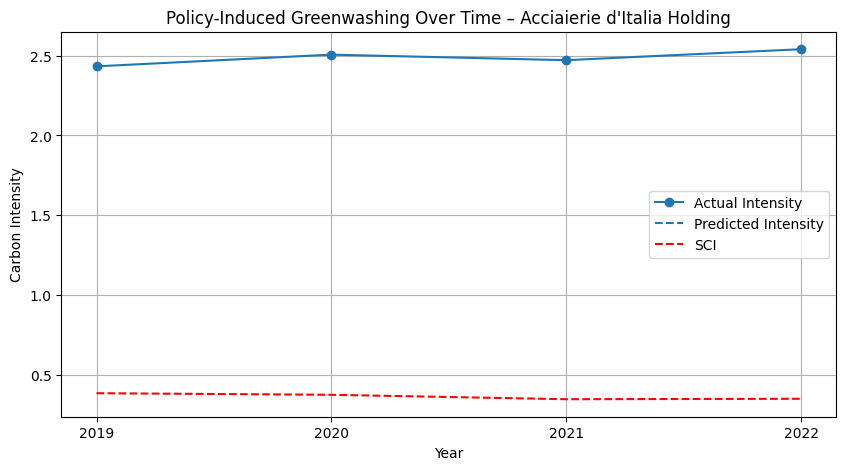

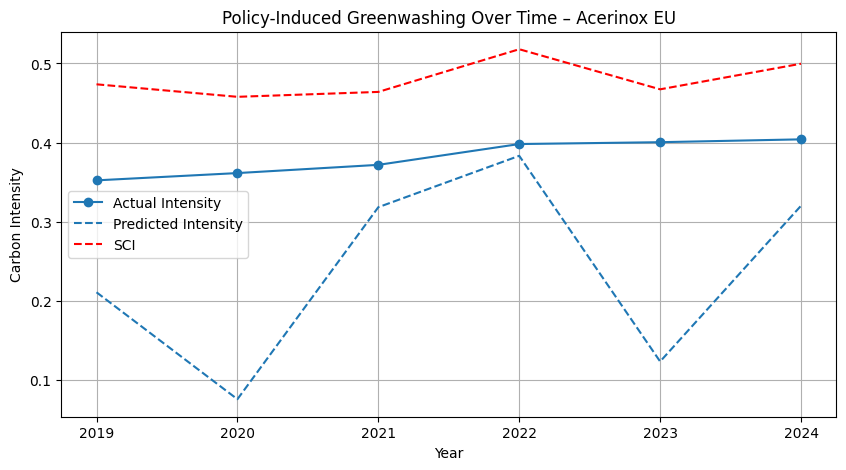

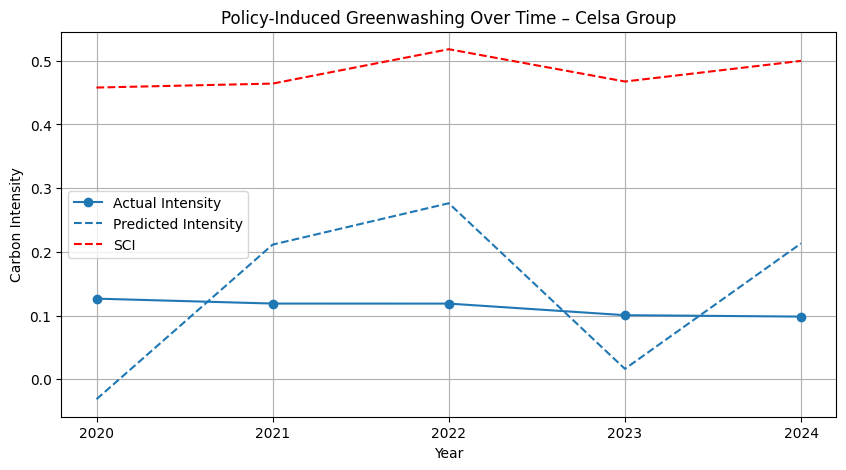

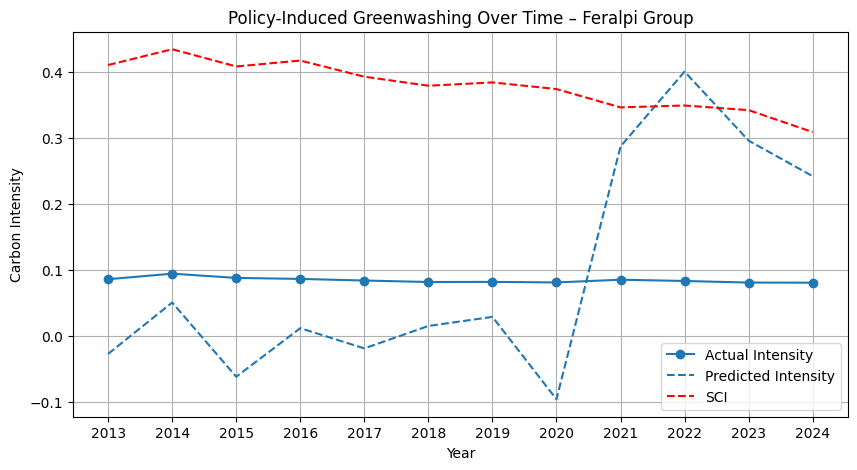

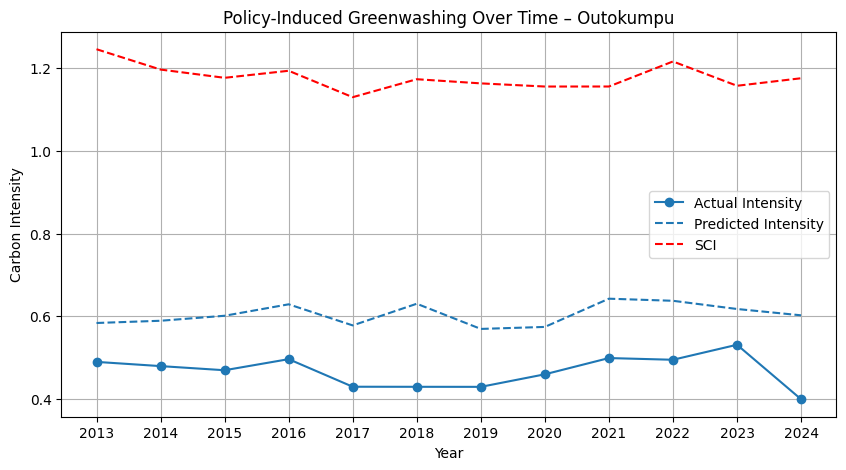

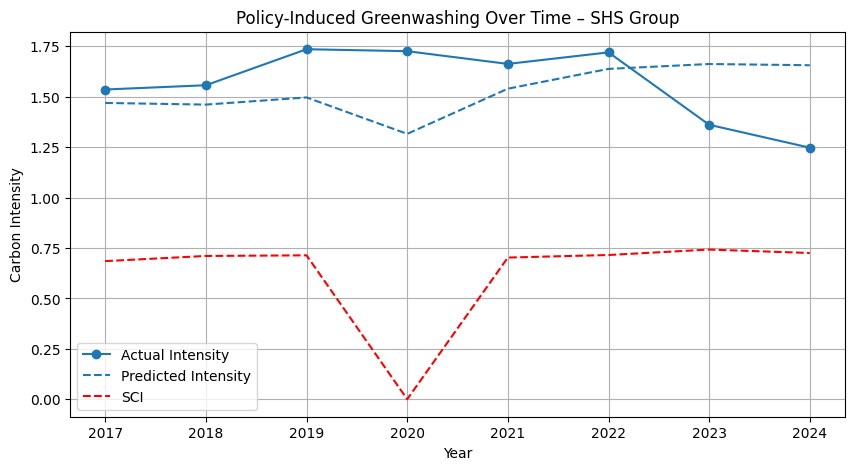

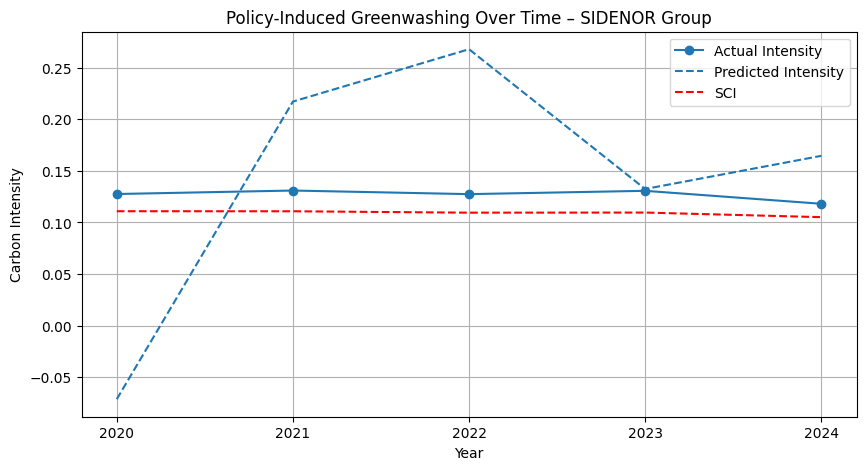

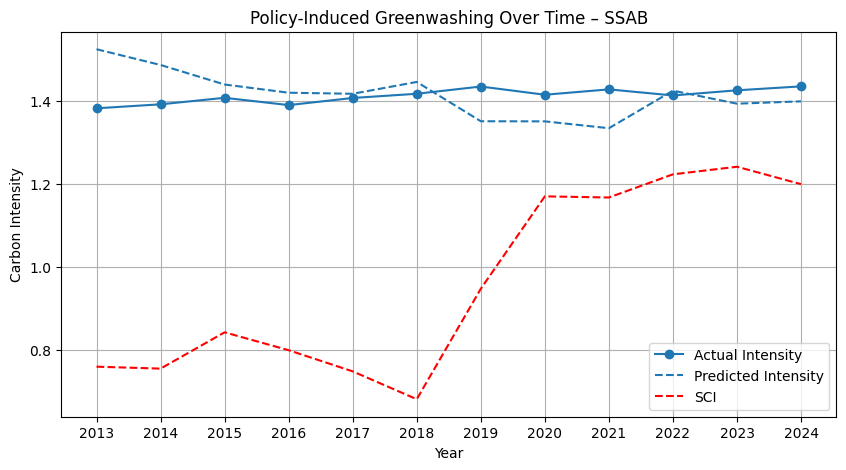

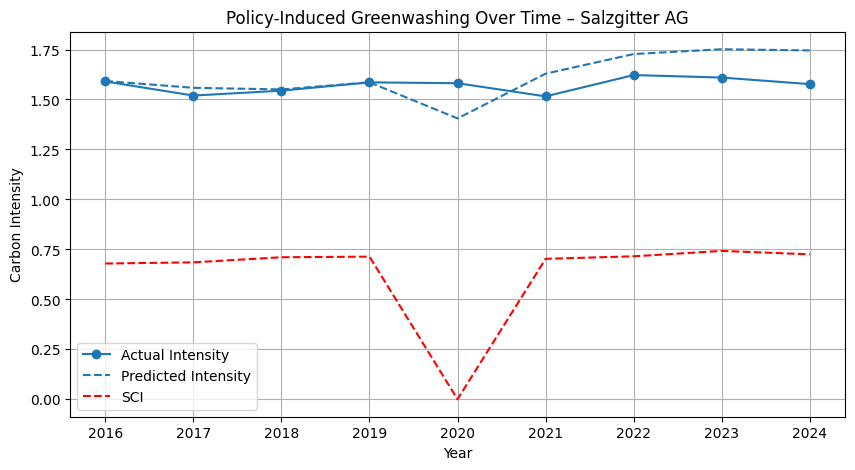

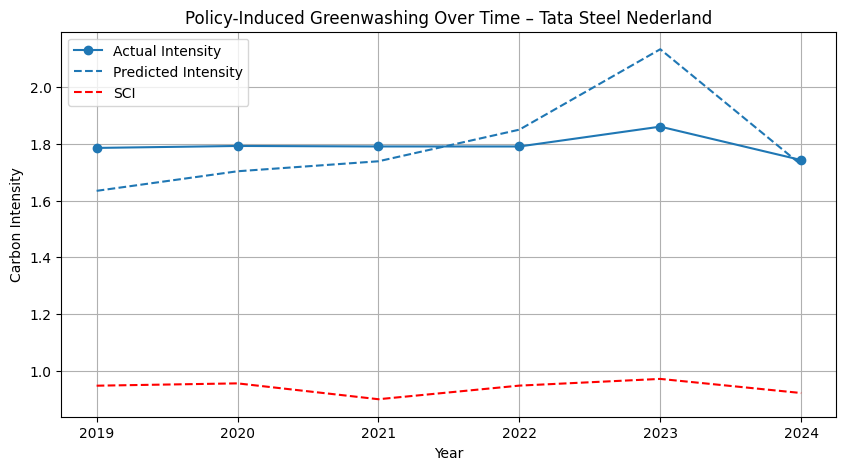

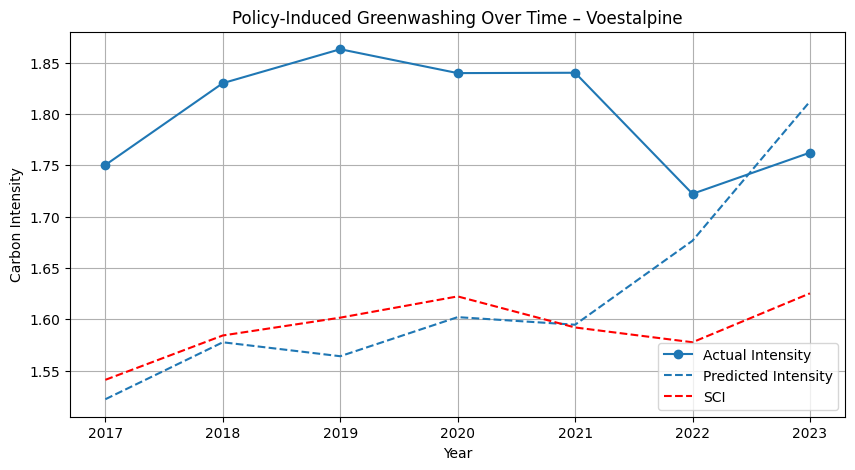

In [22]:
color_ci = 'C0'  # Carbon intensity
color_pr = 'C1'  # Production
color_sc = 'C2'  # Scope 1 emissions

# 1. Make sure you have the prediction column in df_panel
df_panel['pred_ci_tech'] = modB_ci.fitted_values

# 2. Go to long form with firm + year as columns
panel_long = df_panel.reset_index()

# 3. Compute annual averages per firm
agg = (
    panel_long
    .groupby(['company', 'year'])[['carbon_intensity', 'pred_ci_tech', 'SCI']]
    .mean()
    .reset_index()
)

firms = agg['company'].unique()

# 4. Loop over firms and plot one graph per firm
for firm in firms:
    firm_data = agg[agg['company'] == firm]

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        firm_data['year'],
        firm_data['carbon_intensity'],
        marker='o',
        color=color_ci,
        label="Actual Intensity"
    )
    ax.plot(
        firm_data['year'],
        firm_data['pred_ci_tech'],
        linestyle='--',
        color=color_ci,
        label="Predicted Intensity"
    )
    ax.plot(
        firm_data['year'],
        firm_data['SCI'],
        linestyle='--',
        color='red',
        label="SCI"
    )

    ax.set_title(f"Policy-Induced Greenwashing Over Time – {firm}")
    ax.set_ylabel("Carbon Intensity")
    ax.set_xlabel("Year")
    plt.xticks(firm_data['year'].unique())  # force clean labels
    ax.grid(True)
    ax.legend()

    plt.show()

## Firm-Level Policy Protection vs. Carbon Performance (Bubble Plot)

### Purpose of this step

This block prepares and visualizes a **firm-level comparison** between:
- exposure to carbon regulation (ETS free allowances),
- actual emission performance (carbon intensity),
- firm size (production scale),
- and production technology.

The goal is to show **structural differences across firms**, not year-to-year variation.

---

### Data cleaning and firm selection

- We first **reset the panel index** to work with firm and country as regular columns.
- Firms with **missing or zero carbon intensity** are excluded:
  - This avoids distortions from incomplete Scope-1 emissions data.
  - Dropped firms are explicitly reported for transparency.
- Only firms with **valid emissions data** are used in the visualization.

This ensures that every point in the plot represents a **real, comparable emitter**.

---

### Firm-level aggregation

For each firm, we compute **average values across all available years**:
- **Carbon Intensity (CI)** → average Scope-1 emissions per unit of production  
- **ETS Free Allowance Ratio** → average policy protection level  
- **Production** → average output (used for bubble size)  
- **SCI** → average national steel intensity (context variable)

Averaging removes short-term noise and highlights **persistent structural differences**.

---

### How to read the bubble plot

- **X-axis: ETS Free Allowance Ratio**  
  → higher values = more protection from carbon costs

- **Y-axis: Carbon Intensity (CI)**  
  → higher values = more emissions per unit of steel

- **Bubble size: Production**  
  → larger bubbles = larger producers

- **Color: Technology**
  - BF-BOF → coal-based, high-emission technology
  - EAF / EAF Stainless → electricity-based, lower-emission technology

Each bubble represents **one firm’s long-run position** in the policy–performance space.

---

### Key interpretation logic

- Firms in the **upper-right**:  
  → high emissions and high policy protection  
- Firms in the **lower-left**:  
  → low emissions with little protection  
- Technology clustering (by color) highlights that **production technology dominates outcomes**.
- Differences within the same technology show **heterogeneity in performance and exposure**.

This visualization motivates the later econometric and ML analysis by showing that
**policy exposure and technology jointly shape firm emissions**.


C:\Users\aposk\AppData\Local\Temp\ipykernel_9668\566202349.py:84: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter([], [], s=350, c=color, label=tech)
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values



✨ Checking firms for valid CI…

All firms in dataset:
                    company         country
                Celsa Group           Spain
                  Outokumpu         Finland
                       SSAB          Sweden
              Salzgitter AG         Germany
       Tata Steel Nederland     Netherlands
                Voestalpine         Austria
              Tata Steel UK              UK
                Acerinox EU           Spain
Acciaierie d'Italia Holding           Italy
              SIDENOR Group Bulgaria-Greece
              Feralpi Group           Italy
               Nippon Steel           Japan
                   Baosteel           China
                  SHS Group         Germany

👍 No firms dropped

✔ Firms included in firm-avg bubble plot:
                    company         country
                Celsa Group           Spain
                  Outokumpu         Finland
                       SSAB          Sweden
              Salzgitter AG         Germany
  

posx and posy should be finite values


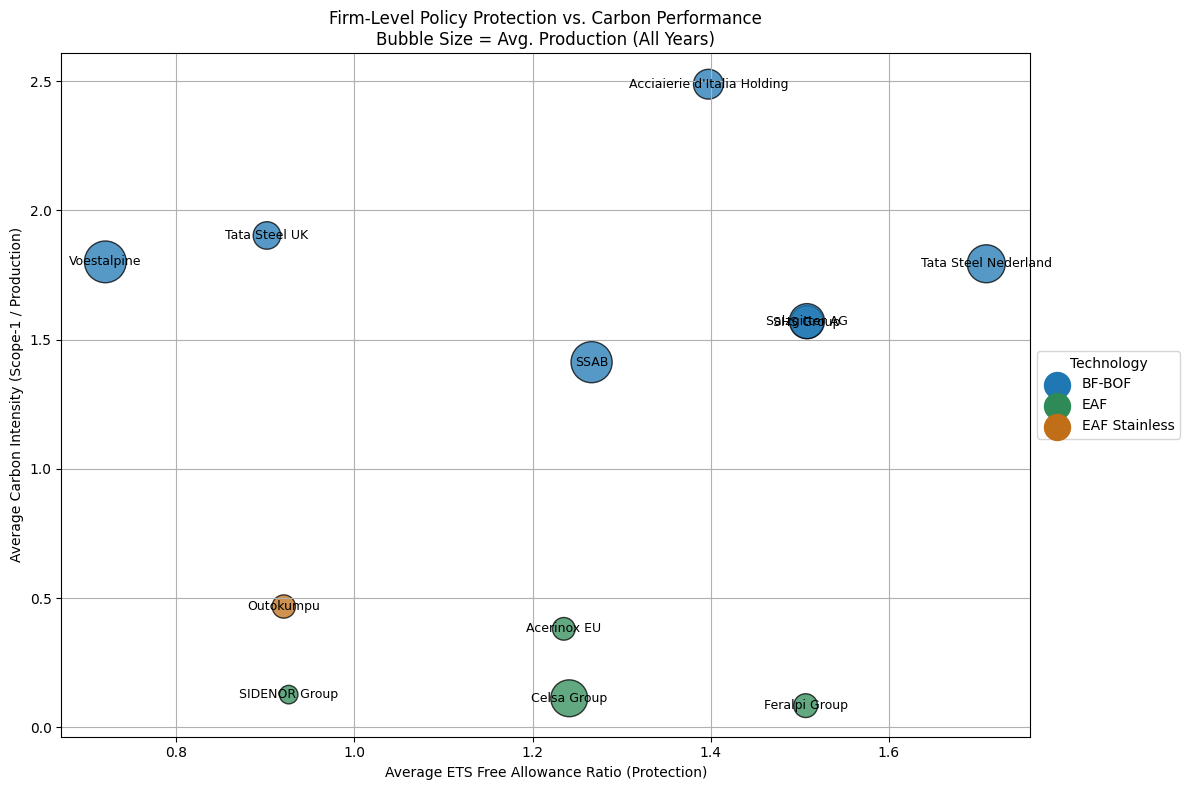

In [23]:
# Reset index to access columns easily
panel_long = df_firms.reset_index()
panel_long = panel_long[
    ~panel_long['company'].str.contains("ArcelorMittal", case=False, na=False)
].copy()

print("\n✨ Checking firms for valid CI…\n")

# All firms (for reporting)
firms_before = panel_long[['company', 'country']].drop_duplicates()
print("All firms in dataset:")
print(firms_before.to_string(index=False))

# Keep only firms with valid CI
valid_mask = panel_long['carbon_intensity'].notna() & (panel_long['carbon_intensity'] > 0)
panel_valid = panel_long[valid_mask]

# Firms excluded from analysis
firms_after = panel_valid[['company', 'country']].drop_duplicates()
dropped = firms_before.merge(firms_after, how='outer', indicator=True)
dropped = dropped[dropped['_merge'] == 'left_only'].drop(columns=['_merge'])

if not dropped.empty:
    print("\n❌ Firms DROPPED (Missing/zero Scope-1 CI):")
    print(dropped.to_string(index=False))
else:
    print("\n👍 No firms dropped")

print("\n✔ Firms included in firm-avg bubble plot:")
print(firms_after.to_string(index=False))

# Calculate firm averages across all available years
df_avg = (
    panel_valid
    .groupby(['company', 'technology', 'country'])
    .agg({
        'carbon_intensity': 'mean',
        'SCI': 'mean',
        'production': 'mean',
        'ETS_free_ratio': 'mean',
    })
    .reset_index()
)

# Bubble sizes: production scaling
size_scale = 6000  # <-- adjust if you want bigger or smaller bubbles
sizes = (df_avg['production'] / df_avg['production'].max()) * size_scale

# Dynamic color mapping by technology
unique_tech = df_avg['technology'].unique()
tech_colors = {'EAF': '#2E8B57', 'BF/BOF': '#C62828', 'EAF Stainless': "#C06E17"}
color_map = {tech: tech_colors.get(tech, plt.cm.tab10(i)) for i, tech in enumerate(unique_tech)}

fig, ax = plt.subplots(figsize=(12, 8))

# Bubble scatter
ax.scatter(
    df_avg['ETS_free_ratio'],  # X-axis
    df_avg['carbon_intensity'],  # Y-axis
    s=sizes,
    alpha=0.75,
    edgecolor='black',
    c=df_avg['technology'].map(color_map)
)

# Bubble labels (firm names)
for _, row in df_avg.iterrows():
    ax.text(
        row['ETS_free_ratio'],
        row['carbon_intensity'],
        row['company'],
        fontsize=9,
        ha='center',
        va='center'
    )

ax.set_xlabel("Average ETS Free Allowance Ratio (Protection)")
ax.set_ylabel("Average Carbon Intensity (Scope-1 / Production)")
ax.set_title("Firm-Level Policy Protection vs. Carbon Performance\nBubble Size = Avg. Production (All Years)")
ax.grid(True)

# Technology legend positioned middle-left outside plot
for tech, color in color_map.items():
    ax.scatter([], [], s=350, c=color, label=tech)
ax.legend(title="Technology", loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()









In [24]:
df_panel.groupby('technology')['carbon_intensity'].mean().sort_values()

technology
EAF              0.160628
EAF Stainless    0.467754
BF-BOF           1.673277
Name: carbon_intensity, dtype: float64

## Forecasting carbon intensity: what this code does

**Step 1 — Learn how firms behave**
We train a Random Forest model on historical firm-level data to learn how carbon intensity responds to:
- carbon regulation exposure (ETS_free_ratio and ETS×BF),
- electricity prices,
- national steel intensity (SCI),
- and production technology.

This model captures **non-linear, firm-specific emission behavior** that simple trend extrapolation would miss.

### --> Random Forest model performance and interpretation

**Out-of-sample performance**
- **R² ≈ 0.97**: the model explains almost all variation in carbon intensity in unseen (future) years.
- **MAE ≈ 0.075**: on average, predictions are very close to observed firm-level carbon intensity.
- Train–test split was **time-based**, so this reflects realistic forecasting ability (no look-ahead bias).

**What drives predictions (feature importance)**
- **Production technology dominates**:
  - `tech_BF-BOF` is the single most important driver → BF-BOF plants are structurally more carbon intensive.
- **Policy exposure matters through technology**:
  - `ETSxBF` ranks second → ETS pressure is most relevant when interacting with high-emission (BF) technology.
- **External and market factors play a secondary role**:
  - `electricity_price` and `SCI` matter, but much less than technology and ETS exposure.
- **Firm-specific effects remain important**:
  - Firm dummies capture persistent differences in operational efficiency and practices.

**Key takeaway**
- Emissions are primarily explained by **technology choice and effective ETS exposure**,  
  while prices and country-level indicators shape outcomes at the margin.
- This supports using the model for **policy scenario analysis**, where changing ETS pressure and technology pathways leads to different emission outcomes.


---

**Step 2 — Build realistic future inputs**
Instead of extrapolating emissions directly, we first project the *drivers*:
- **ETS free allowances** and **SCI** are extrapolated using historical time trends (Business-as-Usual baseline).
- Policy scenarios then modify these trends:
  - **BAU**: continuation of observed policy and technology trends.
  - **Policy tightening**: fewer free allowances and modest efficiency improvements.
  - **Deep technology transition**: strong ETS pressure and structural improvements consistent with hydrogen-compatible steelmaking.

---

**Step 3 — Scenario-based prediction**
Each scenario’s future inputs are fed into the trained Random Forest.
This lets the model **react to policy and technology changes**, rather than assuming emissions follow a fixed trend.

Predictions are aligned to the last observed year to avoid artificial jumps between historical and future values.

---

## How to read the figures

- Firm-level plots show **actual emissions vs. predicted paths** under each scenario.
- EU-average plots summarize how the industry evolves under different policy pathways.
- Percentage-change plots compare scenarios relative to a base year, highlighting **direction and magnitude of change** rather than levels.

Differences across scenarios reflect **policy choices and technology transitions**, not model artefacts.



=== Acerinox EU ===
Train years: [2019, 2020, 2021, 2022]
Test  years: [2023, 2024]

=== Celsa Group ===
Train years: [2020, 2021, 2022]
Test  years: [2023, 2024]

=== Feralpi Group ===
Train years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
Test  years: [2021, 2022, 2023, 2024]

=== Outokumpu ===
Train years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
Test  years: [2021, 2022, 2023, 2024]

=== SHS Group ===
Train years: [2017, 2018, 2019, 2020, 2021]
Test  years: [2022, 2023, 2024]

=== SIDENOR Group ===
Train years: [2020, 2021, 2022]
Test  years: [2023, 2024]

=== SSAB ===
Train years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
Test  years: [2021, 2022, 2023, 2024]

=== Salzgitter AG ===
Train years: [2016, 2017, 2018, 2019, 2020, 2021]
Test  years: [2022, 2023, 2024]

=== Tata Steel Nederland ===
Train years: [2019, 2020, 2021, 2022]
Test  years: [2023, 2024]

=== Voestalpine ===
Train years: [2017, 2018, 2019, 2020]
Test  years: [2021, 2022, 2023]

Final shapes:

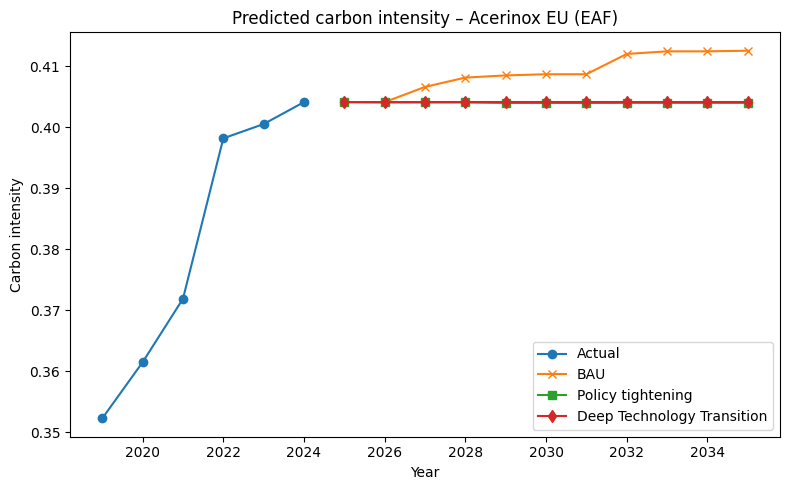

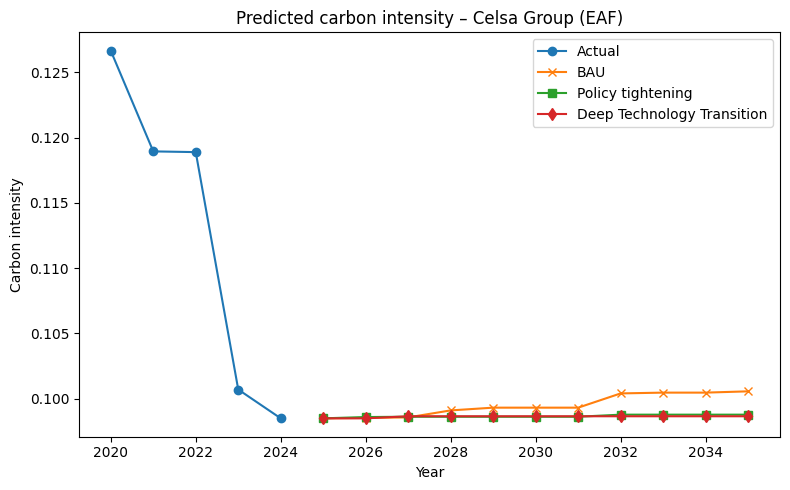

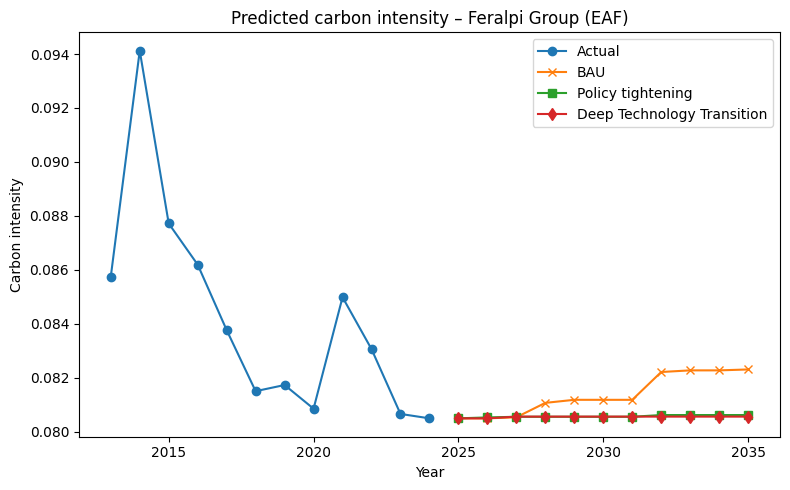

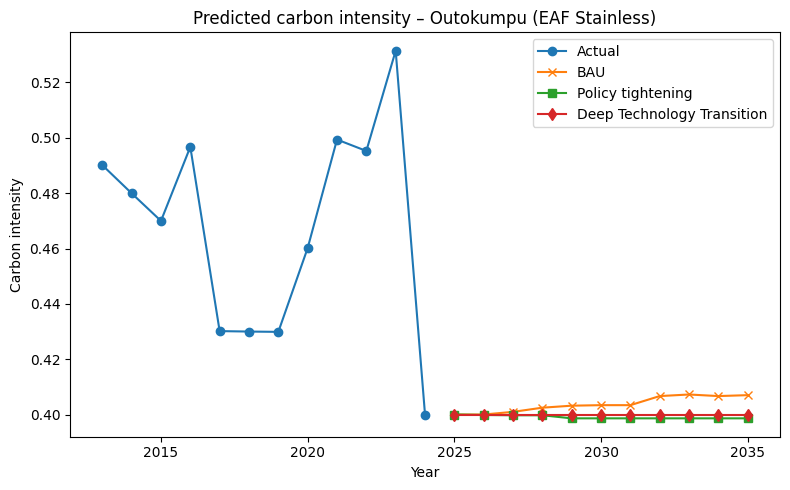

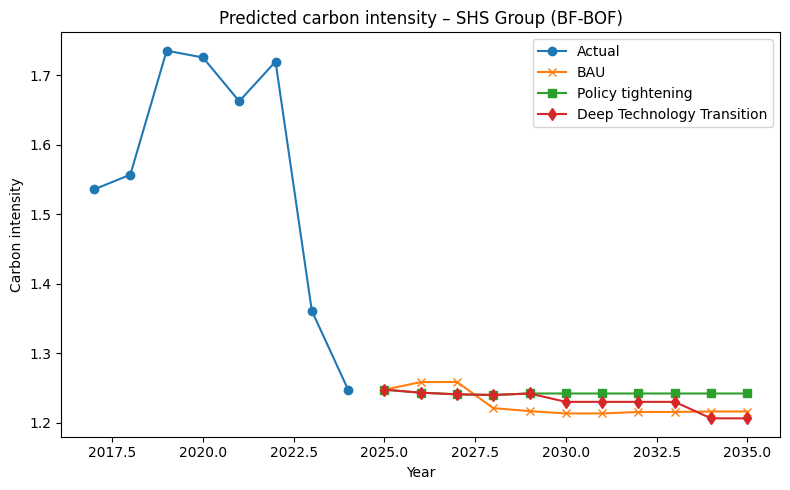

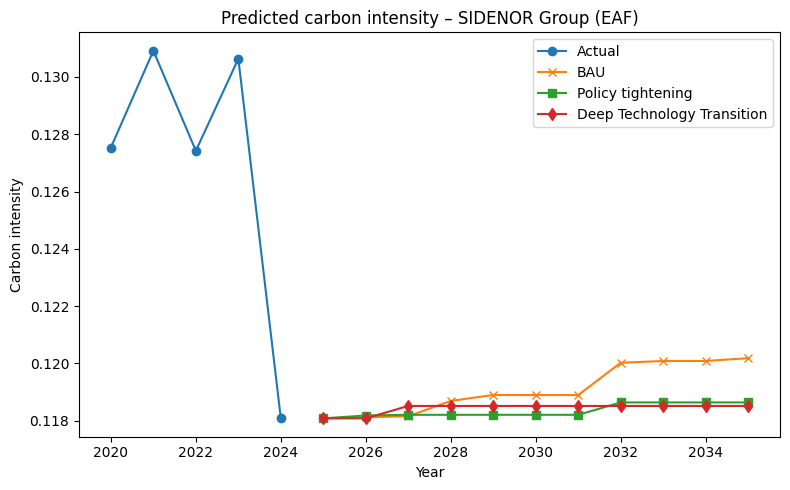

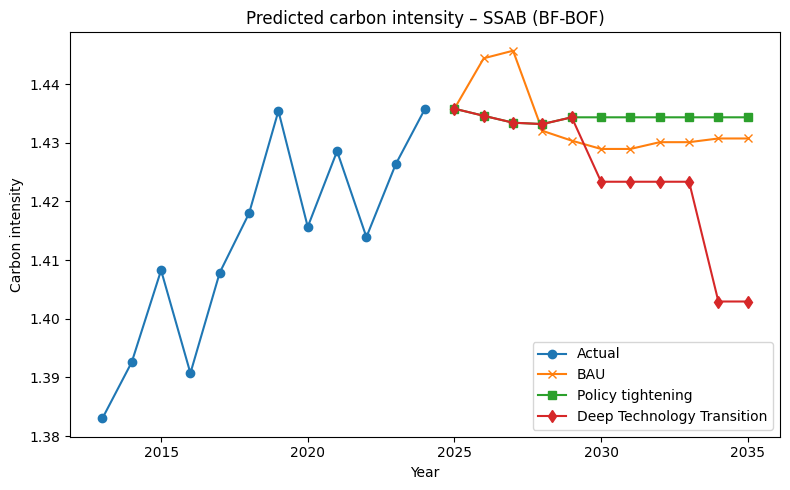

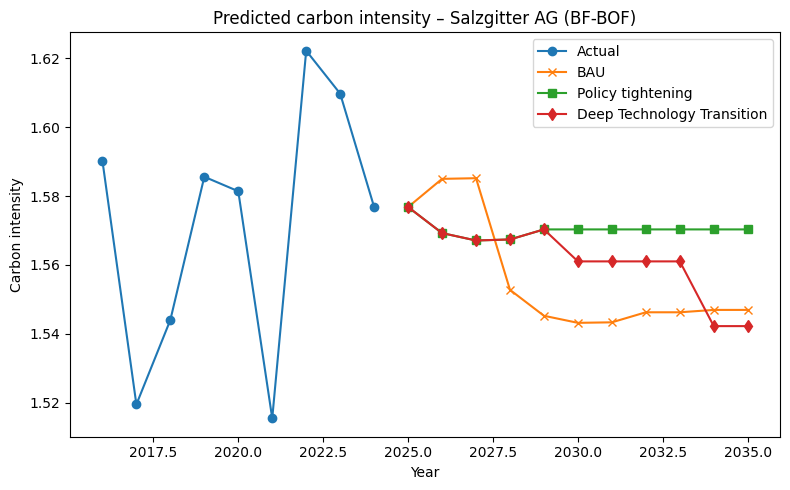

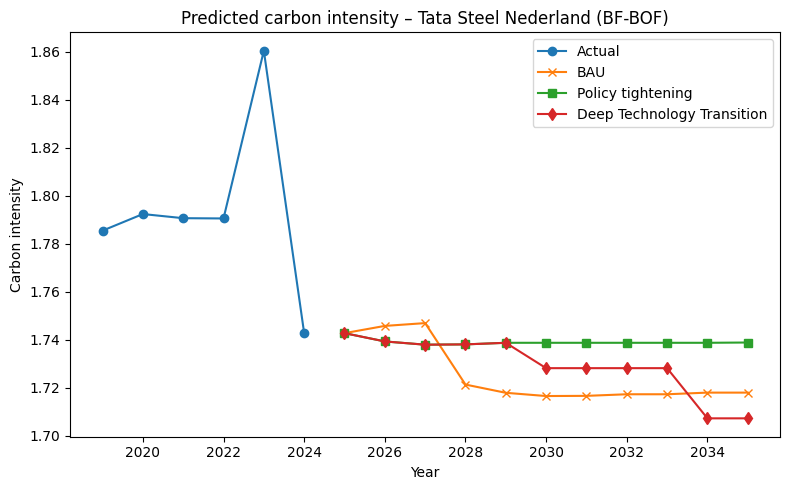

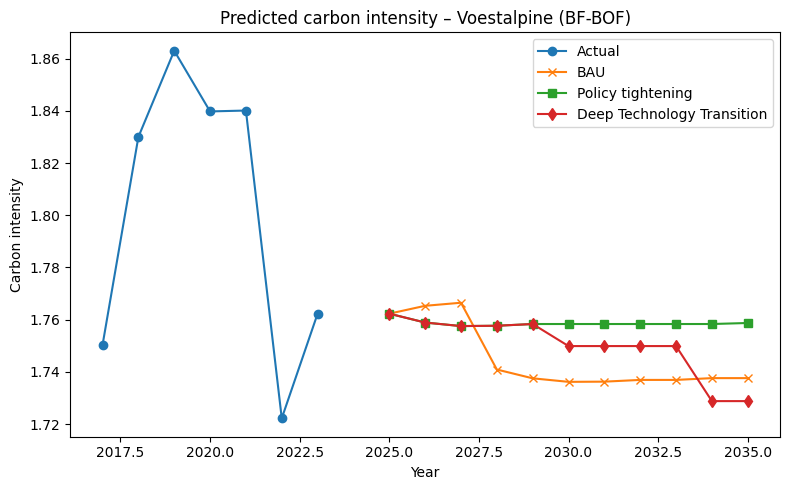

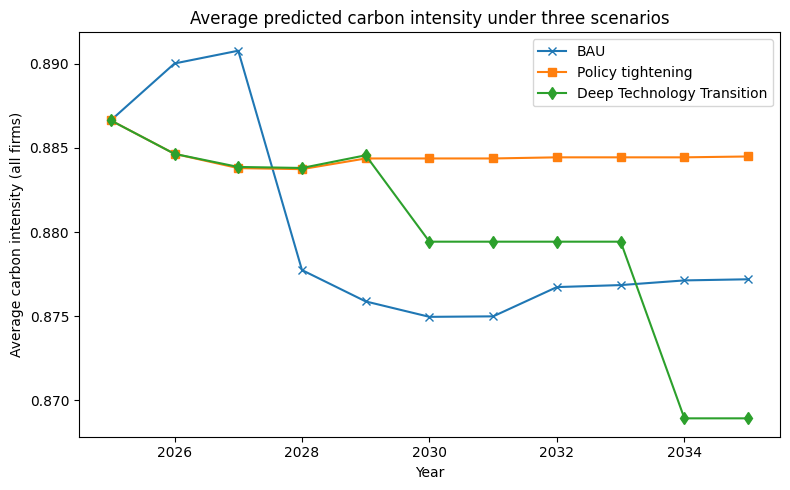

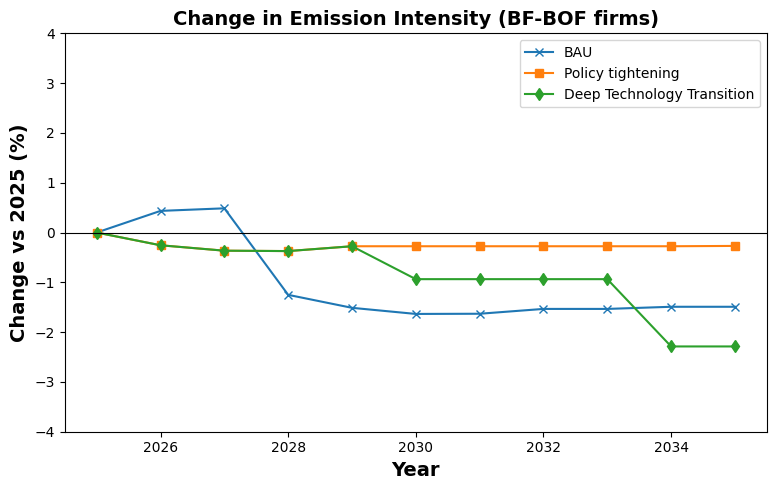

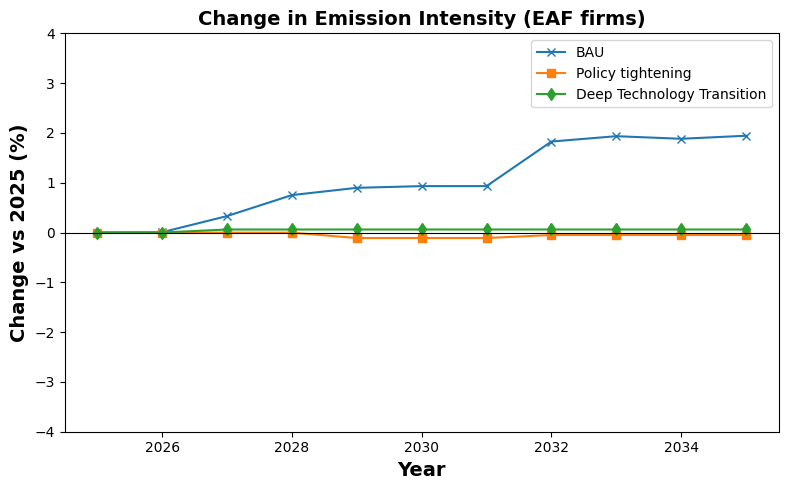

In [25]:
# ===============================================
# 1. STARTING POINT: df_panel
# ===============================================
# Assumptions about df_panel:
# - MultiIndex: ['company', 'year']
# - Columns include at least:
#   'carbon_intensity', 'ETS_free_ratio', 'electricity_price',
#   'SCI', 'client_pressure_score', 'technology'
# - ArcelorMittal already removed
# - Years go up to 2024 (or similar)

# If BFBOF and ETSxBF are not yet created, do it here:
df_panel = df_panel.copy()




# ===============================================
# 2. PREPARE DATA FOR MACHINE LEARNING
# ===============================================


# 1. Bring index to columns
df_ml = df_panel.reset_index().copy()

# 2. Features and target
feature_cols_base = [
    'ETSxBF',
    'electricity_price',
    'SCI',
    'ETS_free_ratio',
    'client_pressure_score'
]
target_col = 'carbon_intensity'

# 3. Drop missing rows (include technology too if you need it for all obs)
df_ml = df_ml.dropna(
    subset=feature_cols_base + [target_col, 'company', 'year', 'technology']
)

# 4. Firm dummies (X part) – keep prefix consistent with scenarios
firm_dummies = pd.get_dummies(df_ml['company'], prefix='', prefix_sep='')
dummy_cols = firm_dummies.columns  # save for future use

# 5. Technology dummies
tech_dummies = pd.get_dummies(df_ml['technology'], prefix='tech')
tech_dummy_cols = tech_dummies.columns  # save for future use

# 6. Final X matrix
X = pd.concat(
    [df_ml[feature_cols_base], tech_dummies, firm_dummies],
    axis=1
)

# 7. Target as Series (y part)
y_series = df_ml[target_col].copy()

dummy_cols = firm_dummies.columns



# ===============================================
# 3. TRAIN–TEST SPLIT (BY YEAR)
# ===============================================
# We split by time, not randomly, to mimic "train on past, test on recent years".


X_train_list = []
X_test_list = []
y_train_list = []
y_test_list = []

for firm, df_firm in df_ml.groupby("company"):
    # sort this firm's rows by year
    df_sorted = df_firm.sort_values("year")
    idx = df_sorted.index              # indices into df_ml (and X, y_series)
    years = df_sorted['year'].tolist() # list of years for this firm

    if len(idx) <= 3:
        # few observations: use all but last for train, last for test
        train_idx = idx[:-1]
        test_idx  = idx[-1:]
        train_years = years[:-1]
        test_years  = years[-1:]
    else:
        # ~70% earliest years for train, rest for test
        split_pos = int(0.7 * len(idx))
        train_idx = idx[:split_pos]
        test_idx  = idx[split_pos:]
        train_years = years[:split_pos]
        test_years  = years[split_pos:]

    # print which years were train/test for this firm
    print(f"\n=== {firm} ===")
    print("Train years:", train_years)
    print("Test  years:", test_years)

    # build train/test sets using the global X and y_series
    X_train_list.append(X.loc[train_idx])
    y_train_list.append(y_series.loc[train_idx])
    X_test_list.append(X.loc[test_idx])
    y_test_list.append(y_series.loc[test_idx])

# concatenate across firms
X_train = pd.concat(X_train_list)
y_train = pd.concat(y_train_list)
X_test  = pd.concat(X_test_list)
y_test  = pd.concat(y_test_list)

print("\nFinal shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)








# ===============================================
# 4. TRAIN RANDOM FOREST REGRESSOR
# ===============================================

rf = RandomForestRegressor(
    n_estimators=500,      # number of trees
    max_depth=None,        # let trees grow until pure/stop
    random_state=42,
    n_jobs=-1              # use all cores
)

rf.fit(X_train, y_train)

# Evaluate on test set
y_pred_test = rf.predict(X_test)

print("\n=== Random Forest Performance on Test Years ===")
print("Test R²: ", r2_score(y_test, y_pred_test))
print("Test MAE:", mean_absolute_error(y_test, y_pred_test))
imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(imp.head(20))


# ===============================================
# 5. BUILD FUTURE BASE PANEL (2025–2035)
# ===============================================
# We start from each firm's last observed year and extend forward.

last_year = int(df_panel.index.get_level_values('year').max())
future_years = list(range(last_year +1, 2035 + 1))

future_years = list(range(last_year +1, 2035 + 1))   # 2025–2035

# Take last observed row per firm (represents 2024 levels)
last_rows = (
    df_ml
      .sort_values('year')
      .groupby('company')
      .last()
)

rows = []
for firm, row in last_rows.iterrows():
    for year in future_years:
        r = row.copy()
        r['company'] = firm
        r['year'] = year
        rows.append(r)

future_base = pd.DataFrame(rows)

# IMPORTANT: We only keep columns we need and ensure BFBOF is present
# (it already exists in df_panel, and was carried into df_ml)
future_base = pd.DataFrame(rows)

# IMPORTANT: We keep technology too, so we can build tech dummies in scenarios
future_base = future_base[
    ['company', 'year', 'technology'] +
    feature_cols_base +     # ['ETSxBF','electricity_price','SCI','ETS_free_ratio','client_pressure_score']
    ['BFBOF']
].copy()


# === Build BAU (business-as-usual) time trends for ETS and SCI from historical data ===


import statsmodels.api as sm

def fit_time_trend(df, col):
    """
    Fit a simple linear trend: col ~ year
    Returns a statsmodels OLS model.
    """
    tmp = (
        df
        .groupby('year')[col]
        .mean()
        .reset_index()
        .dropna(subset=[col])
    )
    X = sm.add_constant(tmp['year'])
    y = tmp[col]
    model = sm.OLS(y, X).fit()
    return model

# Fit trends on your historical panel (all firms)
ets_trend_model = fit_time_trend(df_ml, 'ETS_free_ratio')
sci_trend_model = fit_time_trend(df_ml, 'SCI')

# Build a baseline path for 2025–2035 from these trends
years_future = np.array(future_years)  # you already defined future_years
X_future = sm.add_constant(years_future)

ets_baseline = ets_trend_model.predict(X_future)
sci_baseline = sci_trend_model.predict(X_future)

baseline_paths = pd.DataFrame({
    'year': years_future,
    'ETS_baseline': ets_baseline,
    'SCI_baseline': sci_baseline
})

# Merge these baselines into future_base (one row per firm-year)
future_base = future_base.merge(baseline_paths, on='year', how='left')



# ===============================================
# 6. SCENARIOS USING BASELINE + PANEL/OLS INSIGHT
# ===============================================

# years_ahead still useful for phase timing
years_ahead = future_base['year'] - (last_year + 1)

# --- BAU: just follow the data-driven trend (no extra push) ---
bau = future_base.copy()
bau['ETS_free_ratio'] = bau['ETS_baseline']
bau['SCI']            = bau['SCI_baseline']
bau['ETSxBF']         = bau['ETS_free_ratio'] * bau['BFBOF']

# --- Policy Tightening: stronger ETS + mildly faster SCI improvement ---
tight = future_base.copy()

# Sharper reduction in free allowances (PanelOLS says ETS_free_ratio is powerful)
tight['ETS_free_ratio'] = tight['ETS_baseline'] * 0.8  # 20% lower than baseline
# Slightly faster tech progress
tight['SCI'] = tight['SCI_baseline'] * 0.97           # ~3% better than baseline
tight['ETSxBF'] = tight['ETS_free_ratio'] * tight['BFBOF']

# --- Hydrogen / Deep Transition: very strong ETS + big SCI improvements after 2030 ---
h2 = future_base.copy()

# Aggressive ETS tightening especially after 2030 (guided by BF coefficients)
h2['ETS_free_ratio'] = np.where(
    h2['year'] < 2030,
    h2['ETS_baseline'] * 0.7,   # 30% stricter than baseline pre-2030
    h2['ETS_baseline'] * 0.4    # 60% stricter than baseline post-2030
)

# SCI: modestly better than baseline pre-2030; much better after 2030 (hydrogen, etc.)
h2['SCI'] = np.where(
    h2['year'] < 2030,
    h2['SCI_baseline'] * 0.97,  # +3% improvement
    h2['SCI_baseline'] * 0.90   # +10% improvement vs baseline
)

h2['ETSxBF'] = h2['ETS_free_ratio'] * h2['BFBOF']



# ===============================================
# 7. BUILD FEATURE MATRICES FOR EACH SCENARIO
# ===============================================
# We need the same structure as X_train:
#   [feature_cols_base] + firm dummies with the SAME columns (dummy_cols)

def build_X_for_scenario(df_scen):
    """
    df_scen: DataFrame with columns:
        'company', 'year', 'technology', feature_cols_base, 'BFBOF'
    Returns:
        scen_flat: df with company, year, technology, features
        X_scen:    feature matrix with EXACTLY the same columns (name + order)
                  as X_train used in rf.fit()
    """
    scen_flat = df_scen.copy()

    # Base features in same order as training
    feat = scen_flat[feature_cols_base].copy()

    # Firm dummies, same prefix and columns as training
    d_firm = pd.get_dummies(scen_flat['company'], prefix='', prefix_sep='')
    d_firm = d_firm.reindex(columns=dummy_cols, fill_value=0)

    # Technology dummies, same columns as training
    d_tech = pd.get_dummies(scen_flat['technology'], prefix='tech')
    d_tech = d_tech.reindex(columns=tech_dummy_cols, fill_value=0)

    # Combine in SAME logical order as training: features + tech + firm
    X_raw = pd.concat([feat, d_tech, d_firm], axis=1)

    # FINAL STEP: enforce columns to match X_train exactly (names + order)
    X_scen = X_raw.reindex(columns=X_train.columns, fill_value=0)

    return scen_flat, X_scen


bau_scen,   X_bau   = build_X_for_scenario(bau)
tight_scen, X_tight = build_X_for_scenario(tight)
h2_scen,    X_h2    = build_X_for_scenario(h2)


# ===============================================
# 8. PREDICT CARBON INTENSITY FOR EACH SCENARIO
# ===============================================

bau_scen['CI_pred_BAU']     = rf.predict(X_bau)
tight_scen['CI_pred_Tight'] = rf.predict(X_tight)
h2_scen['CI_pred_H2']       = rf.predict(X_h2)

# Keep only relevant columns
bau_scen   = bau_scen[['company', 'year', 'CI_pred_BAU']]
tight_scen = tight_scen[['company', 'year', 'CI_pred_Tight']]
h2_scen    = h2_scen[['company', 'year', 'CI_pred_H2']]

# Merge into a single future predictions table
future_preds = (
    bau_scen
      .merge(tight_scen, on=['company','year'])
      .merge(h2_scen,    on=['company','year'])
      .set_index(['company','year'])
      .sort_index()
)

print("\n=== Example of future predictions (head) ===")
print(future_preds.head())


first_future_year = future_years[0]  # e.g. 2025
rows_adj = []

for firm, df_firm in future_preds.reset_index().groupby('company'):
    df_firm = df_firm.sort_values('year').copy()

    # last actual CI for this firm
    hist_firm = (
        df_ml[df_ml['company'] == firm]
        .sort_values('year')
    )
    ci_last_actual = hist_firm['carbon_intensity'].iloc[-1]

    # predictions in the first future year
    row_2025 = df_firm.loc[df_firm['year'] == first_future_year]

    ci_bau_first   = row_2025['CI_pred_BAU'].iloc[0]
    ci_tight_first = row_2025['CI_pred_Tight'].iloc[0]
    ci_h2_first    = row_2025['CI_pred_H2'].iloc[0]

    # separate gaps per scenario
    gap_bau   = ci_bau_first   - ci_last_actual
    gap_tight = ci_tight_first - ci_last_actual
    gap_h2    = ci_h2_first    - ci_last_actual

    # apply each gap to its scenario
    df_firm['CI_BAU_adj']   = df_firm['CI_pred_BAU']   - gap_bau
    df_firm['CI_Tight_adj'] = df_firm['CI_pred_Tight'] - gap_tight
    df_firm['CI_H2_adj']    = df_firm['CI_pred_H2']    - gap_h2

    rows_adj.append(
        df_firm[['company','year','CI_BAU_adj','CI_Tight_adj','CI_H2_adj']]
    )

future_preds_adj = (
    pd.concat(rows_adj)
      .set_index(['company','year'])
      .sort_index()
)
     



# ===============================================
# 9. OPTIONAL: PLOT FOR ALL THE FIRMS
# ===============================================

firms = sorted(df_ml['company'].unique())

for firm_name in firms:

    # --- historical data ---
    hist = (
        df_ml[df_ml['company'] == firm_name]
        .groupby('year', as_index=False)['carbon_intensity']
        .mean()
        .sort_values('year')
    )

    # --- get most recent technology entry ---
    tech_info = (
        df_ml[df_ml['company'] == firm_name]
        .sort_values('year')['technology']
        .iloc[-1]   # technology in latest observed year
    )

    # --- future adjusted predictions ---
    fut = (
        future_preds_adj
          .reset_index()
          .query("company == @firm_name")
          .sort_values('year')
    )

    if fut.empty or hist.empty:
        continue

    # --- plot ---
    plt.figure(figsize=(8,5))
    plt.plot(hist['year'], hist['carbon_intensity'], label='Actual', marker='o')
    plt.plot(fut['year'], fut['CI_BAU_adj'],   label='BAU',               marker='x')
    plt.plot(fut['year'], fut['CI_Tight_adj'], label='Policy tightening', marker='s')
    plt.plot(fut['year'], fut['CI_H2_adj'],    label='Deep Technology Transition',   marker='d')

    plt.xlabel("Year")
    plt.ylabel("Carbon intensity")
    plt.title(f"Predicted carbon intensity – {firm_name} ({tech_info})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # save
    #safe_name = firm_name.replace("/", "_").replace("\\", "_")
    #plt.savefig(os.path.join(out_dir, f"CI_{safe_name}.png"), dpi=150)
    plt.close()





# ===============================================
# 10. OPTIONAL: PLOT EU AVERAGE CI PER SCENARIO
# ===============================================

# Average across all firms by year
avg_future = (
    future_preds_adj
      .reset_index()
      .groupby('year')[['CI_BAU_adj','CI_Tight_adj','CI_H2_adj']]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))
plt.plot(avg_future['year'], avg_future['CI_BAU_adj'],   label='BAU',               marker='x')
plt.plot(avg_future['year'], avg_future['CI_Tight_adj'], label='Policy tightening', marker='s')
plt.plot(avg_future['year'], avg_future['CI_H2_adj'],    label='Deep Technology Transition',   marker='d')

plt.xlabel("Year")
plt.ylabel("Average carbon intensity (all firms)")
plt.title("Average predicted carbon intensity under three scenarios")
plt.legend()
plt.tight_layout()
plt.show()


# ===============================================
# 11. Average CI per scenario, split by technology
# ===============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- helper: % change vs base year ----------

def pct_change_from_base(df, cols, base_year):
    """
    Compute % change of each column in `cols` relative to base_year.
    (value_t - value_base) / value_base * 100

    df:   DataFrame with a 'year' column and scenario columns
    cols: list of columns to transform
    base_year: int, the year to use as reference (e.g. 2026)
    """
    df = df.copy()

    base_row = df.loc[df['year'] == base_year]
    if base_row.empty:
        raise ValueError(f"Base year {base_year} not found in DataFrame.")

    base_vals = base_row.iloc[0][cols]

    for c in cols:
        df[f"{c}_pct_vs_{base_year}"] = (df[c] - base_vals[c]) / base_vals[c] * 100

    return df


# 1. Classify firms by their latest technology
firm_latest_tech = (
    df_ml.sort_values('year')
         .groupby('company')['technology']
         .last()
)

# BF-BOF firms
bf_firms = firm_latest_tech[firm_latest_tech.str.contains("BF", case=False)].index

# EAF firms (includes EAF Stainless etc.)
eaf_firms = firm_latest_tech[firm_latest_tech.str.contains("EAF", case=False)].index

# choose your base year for comparison (adjust if needed)
base_year = 2025

cols = ['CI_BAU_adj', 'CI_Tight_adj', 'CI_H2_adj']


# ---------- BF-BOF AVERAGE ----------
bf_future = (
    future_preds_adj
      .reset_index()
      .query("company in @bf_firms")
      .groupby('year')[cols]
      .mean()
      .reset_index()
)

# % change vs base_year for BF-BOF
bf_future_pct = pct_change_from_base(bf_future, cols, base_year)

# only plot from base_year onwards (so first point is 0%)
bf_plot = bf_future_pct[bf_future_pct['year'] >= base_year]

plt.figure(figsize=(8,5))
plt.plot(bf_plot['year'], bf_plot[f'CI_BAU_adj_pct_vs_{base_year}'],
         label='BAU', marker='x')
plt.plot(bf_plot['year'], bf_plot[f'CI_Tight_adj_pct_vs_{base_year}'],
         label='Policy tightening', marker='s')
plt.plot(bf_plot['year'], bf_plot[f'CI_H2_adj_pct_vs_{base_year}'],
         label='Deep Technology Transition', marker='d')

plt.axhline(0, color='black', linewidth=0.8)

plt.xlabel("Year", fontsize=14, fontweight="bold")
plt.ylabel(f"Change vs {base_year} (%)", fontsize=14, fontweight="bold")
plt.title("Change in Emission Intensity (BF-BOF firms)",
          fontsize=14, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.ylim(-4, 4)
plt.show()


# ---------- EAF AVERAGE ----------
eaf_future = (
    future_preds_adj
      .reset_index()
      .query("company in @eaf_firms")
      .groupby('year')[cols]
      .mean()
      .reset_index()
)

# % change vs base_year for EAF
eaf_future_pct = pct_change_from_base(eaf_future, cols, base_year)

# only plot from base_year onwards
eaf_plot = eaf_future_pct[eaf_future_pct['year'] >= base_year]

plt.figure(figsize=(8,5))
plt.plot(eaf_plot['year'], eaf_plot[f'CI_BAU_adj_pct_vs_{base_year}'],
         label='BAU', marker='x')
plt.plot(eaf_plot['year'], eaf_plot[f'CI_Tight_adj_pct_vs_{base_year}'],
         label='Policy tightening', marker='s')
plt.plot(eaf_plot['year'], eaf_plot[f'CI_H2_adj_pct_vs_{base_year}'],
         label='Deep Technology Transition', marker='d')

plt.axhline(0, color='black', linewidth=0.8)

plt.xlabel("Year", fontsize=14, fontweight="bold")
plt.ylabel(f"Change vs {base_year} (%)", fontsize=14, fontweight="bold")
plt.title("Change in Emission Intensity (EAF firms)",
          fontsize=14, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.ylim(-4, 4)
plt.show()










## 🌍 Real-world correspondence

### The Hydrogen scenario matches:


| Policy / Industry Plan              | Target timing |
| ----------------------------------- | ------------- |
| EU Hydrogen Backbone infrastructure | 2030–2032     |
| First commercial green-steel plants | 2029–2032     |
| SSAB fossil-free steel              | by 2030       |
| Salzgitter SALCOS transformation    | 2029–2033     |
| CBAM full implementation            | 2032          |
| Free ETS allowances phase-out       | 2034–2035     |

